In [1]:
import geopandas as gpd
import pypsa
from pathlib import Path
import matplotlib.pyplot as plt
from typing import Optional
import pandas as pd
from shapely.geometry import Point, LineString
from matplotlib.lines import Line2D

In [2]:
REGION = "new_england" # "caiso" or "new_england"

if REGION == "caiso":
    CLUSTERS = 4
    SIMPL = 80
else:
    CLUSTERS = 6
    SIMPL = 120

SHAPES_DIR = Path("..", "data", "introduction", "regions", REGION)
FIGURES = Path("..","..","figures","nat_gas_utilization")

BA_MAP = {
    "p129":"VT", 
    "p130":"NH", 
    "p131":"MA", 
    "p132":"CT", 
    "p133":"RI", 
    "p134":"ME", 
}

CONNECTIONS = [
    ("NY", "CT"),
    ("NY", "MA"),
    ("NB", "ME"),
    ("QC", "NH"),
    ("VT", "QC"),
    ("RI", "CT"),
    ("MA", "CT"),
    ("NH", "ME"),
    ("NH", "MA"),
    ("RI", "MA"),
    ("VT", "NH"),
]

In [3]:
def create_geodataframe(shapes_dir: str) -> gpd.GeoDataFrame:
    states = gpd.read_file(Path(shapes_dir, f"regions_onshore_s{SIMPL}_{CLUSTERS}m.geojson"), crs=4326).set_index("name")
    states = states.rename(index=BA_MAP)
    states = states.set_crs(4326)
    
    points = states.copy()
    points["geometry"] = points.geometry.centroid

    extra = gpd.GeoDataFrame(
        [
            ["QC", Point(-71.893122, 46.758815)],
            ["NY", Point(-75.146312, 42.714923)],
            ["NB", Point(-66.379684, 46.714044)],
        ],
        columns=["name", "geometry"]
    ).set_index("name")
    extra.crs = 4326
    
    points = pd.concat([points, extra])
    
    lines = []
    for a, b in CONNECTIONS:
        if a in points.index and b in points.index:
            p1 = points.loc[a].geometry
            p2 = points.loc[b].geometry
            lines.append(LineString([p1, p2]))

    lines = gpd.GeoDataFrame(
        geometry=lines,
        crs=4326
    )

    return pd.concat([states, points, lines])

In [4]:
def plot_map(gdf: gpd.GeoDataFrame) -> tuple[plt.figure, plt.axes]:
    
    fig, ax = plt.subplots(figsize=(8, 8))

    polygons = gdf[gdf.geometry.geom_type.isin(["Polygon", "MultiPolygon"])]
    points = gdf[gdf.geometry.geom_type == "Point"]
    lines = gdf[gdf.geometry.geom_type == "LineString"]

    polygons.plot(ax=ax, edgecolor="blue", facecolor="none", linewidth=1)
    points.plot(ax=ax, color="red", markersize=40, zorder=3)
    lines.plot(
        ax=ax,
        color="black",
        linewidth=1,
        linestyle="--",
        zorder=2
    )

    for name, row in points.iterrows():
        ax.annotate(
            name,
            (row.geometry.x, row.geometry.y),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            fontsize=16
        )

    ax.set_axis_off()
    return fig, ax

/home/trevor/repos/pypsa-demand-response/.venv/lib/python3.13/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver GeoJSON does not support open option CRS
  return ogr_read(
/tmp/ipykernel_3902425/1084149716.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points["geometry"] = points.geometry.centroid


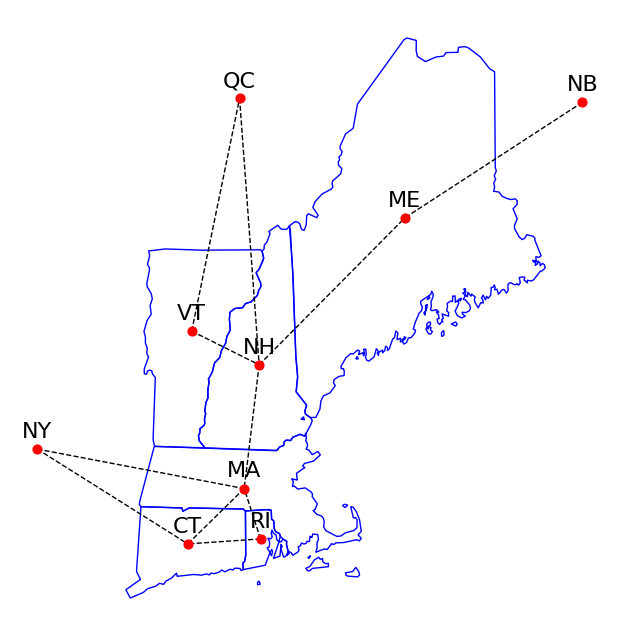

In [5]:
gdf = create_geodataframe(SHAPES_DIR)
fig, _ = plot_map(gdf)
save_f = Path(FIGURES, f"{REGION}_connections.png")
save_f.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(save_f, dpi=300)

In [6]:
def apply_import_export_names(name: str) -> str:
    states = name.split(" ")
    if sorted(states) == states:
        return f"{name} exports"
    else:
        name = f"{states[1]} {states[0]}"
        return f"{name} imports"

In [7]:
def get_utilization(n: pypsa.Network) -> dict[str, pd.DataFrame]:
    p_nom_opt = n.links[n.links.carrier.isin(["gas pipeline", "gas trade"])].p_nom_opt
    p = n.links_t["p0"][p_nom_opt.index]
    utilization = p.div(p_nom_opt, axis=1) * 100
    utilization = utilization.dropna(axis=1)
    cols = {x:apply_import_export_names(" ".join(x.split(" ")[0:2])) for x in utilization.columns}
    utilization = utilization.rename(columns=cols)
    connections = utilization.columns.str.split(" ").str[0:2]
    connections = list(set(map(tuple, connections)))
    data = {}
    for connection in connections:
        name = " ".join(connection)
        cols = [x for x in utilization.columns if x.startswith(name)]
        data[name] = utilization[cols].droplevel(0)
        rename = {x:x.split(" ")[-1].capitalize() for x in data[name].columns}
        data[name] = data[name].rename(columns=rename)
    return data


In [8]:
def plot_utilization(n) -> tuple[plt.figure, plt.axes]:
    data = get_utilization(n)
    
    legend_colors = {
        "Imports": "tab:blue",
        "Exports": "tab:orange"
    }
    
    ncols = 2
    nrows = (len(data) + 1) // ncols
    
    fig, axs = plt.subplots(nrows, ncols, figsize=(12, nrows * 3))
    
    plt.subplots_adjust(
        left=0.1,
        right=0.9,
        bottom=0.1,
        top=0.9,
        wspace=0.2,
        hspace=0.33 
    )
    
    for i, (name, df) in enumerate[tuple[str, pd.DataFrame]](data.items()):
        row = i // ncols
        col = i % ncols
        ax = axs[row, col]
        df.plot(ax=ax, kind="line")
        ax.set_title(f"From {name.split(' ')[0]} to {name.split(' ')[1]}")
        
        ax.set_xlabel("")
        ax.set_ylabel("Utilization (%)")
        
        ax.set_ylim(0, 102)
        
    legend_handles = [
        Line2D([0], [0], color=legend_colors["Imports"], label="Imports"),
        Line2D([0], [0], color=legend_colors["Exports"], label="Exports"),
    ]

    for ax in axs.flat:
        ax.legend(loc= "upper left", bbox_to_anchor=(0, 1.02), title="", facecolor="white", handles=legend_handles)

    return fig, axs

INFO:pypsa.io:Imported network elec_s120_c6m_ec_lv1.0_1h-TCT_E-G.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores


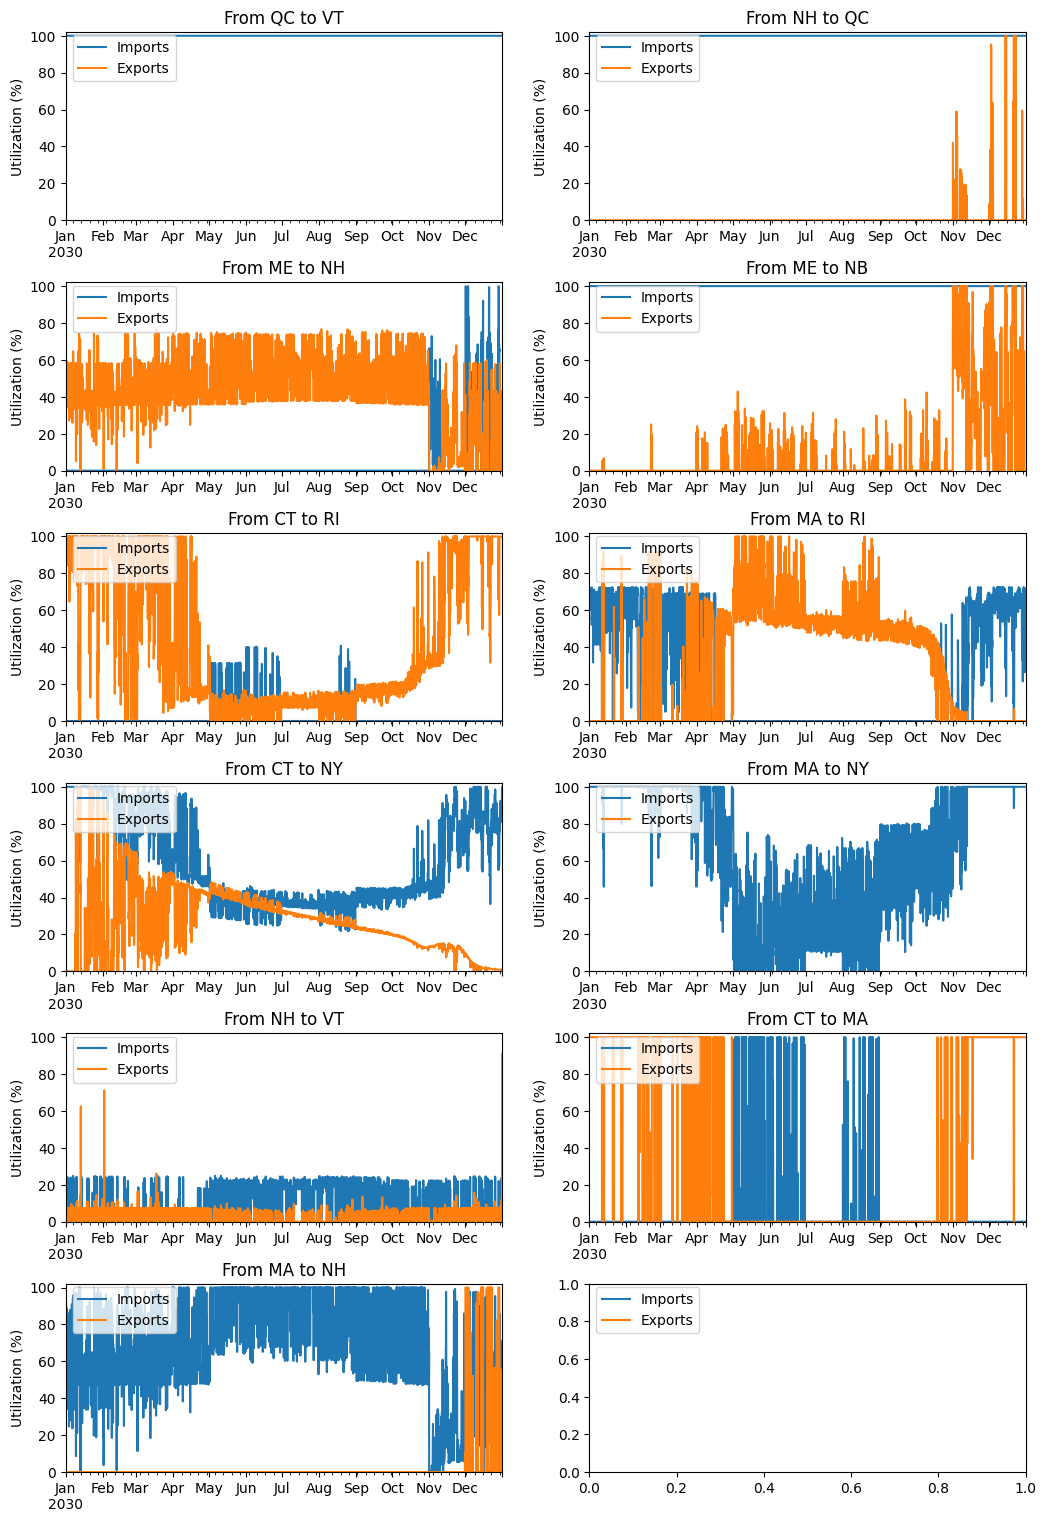

In [9]:
scenario = "lgas"
NETWORK = Path("..", "data", REGION, "raw", scenario, "networks", f"elec_s{SIMPL}_c{CLUSTERS}m_ec_lv1.0_1h-TCT_E-G.nc")
n = pypsa.Network(NETWORK)
fig, _ = plot_utilization(n)
save_f = Path(FIGURES, f"{scenario}.png")
save_f.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(save_f, dpi=300, bbox_inches="tight")

INFO:pypsa.io:Imported network elec_s120_c6m_ec_lv1.0_1h-TCT_E-G.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores


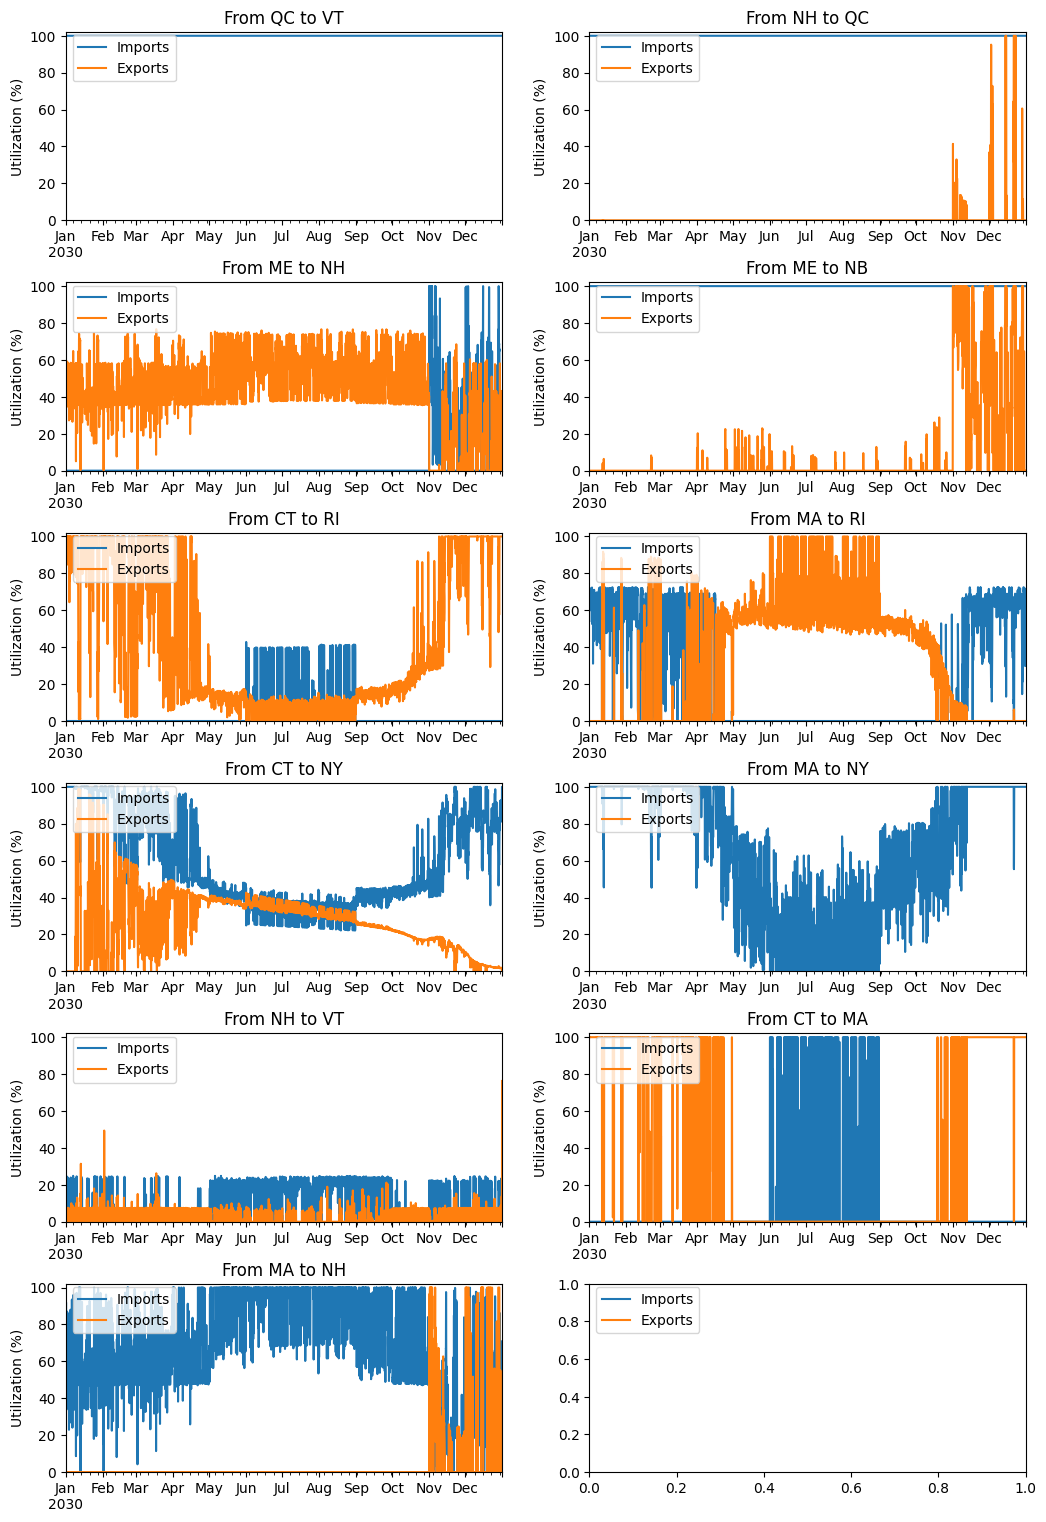

In [10]:
scenario = "mgas"
NETWORK = Path("..", "data", REGION, "raw", scenario, "networks", f"elec_s{SIMPL}_c{CLUSTERS}m_ec_lv1.0_1h-TCT_E-G.nc")
n = pypsa.Network(NETWORK)
fig, _ = plot_utilization(n)
save_f = Path(FIGURES, f"{scenario}.png")
save_f.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(save_f, dpi=300, bbox_inches="tight")

INFO:pypsa.io:Imported network elec_s120_c6m_ec_lv1.0_1h-TCT_E-G.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores


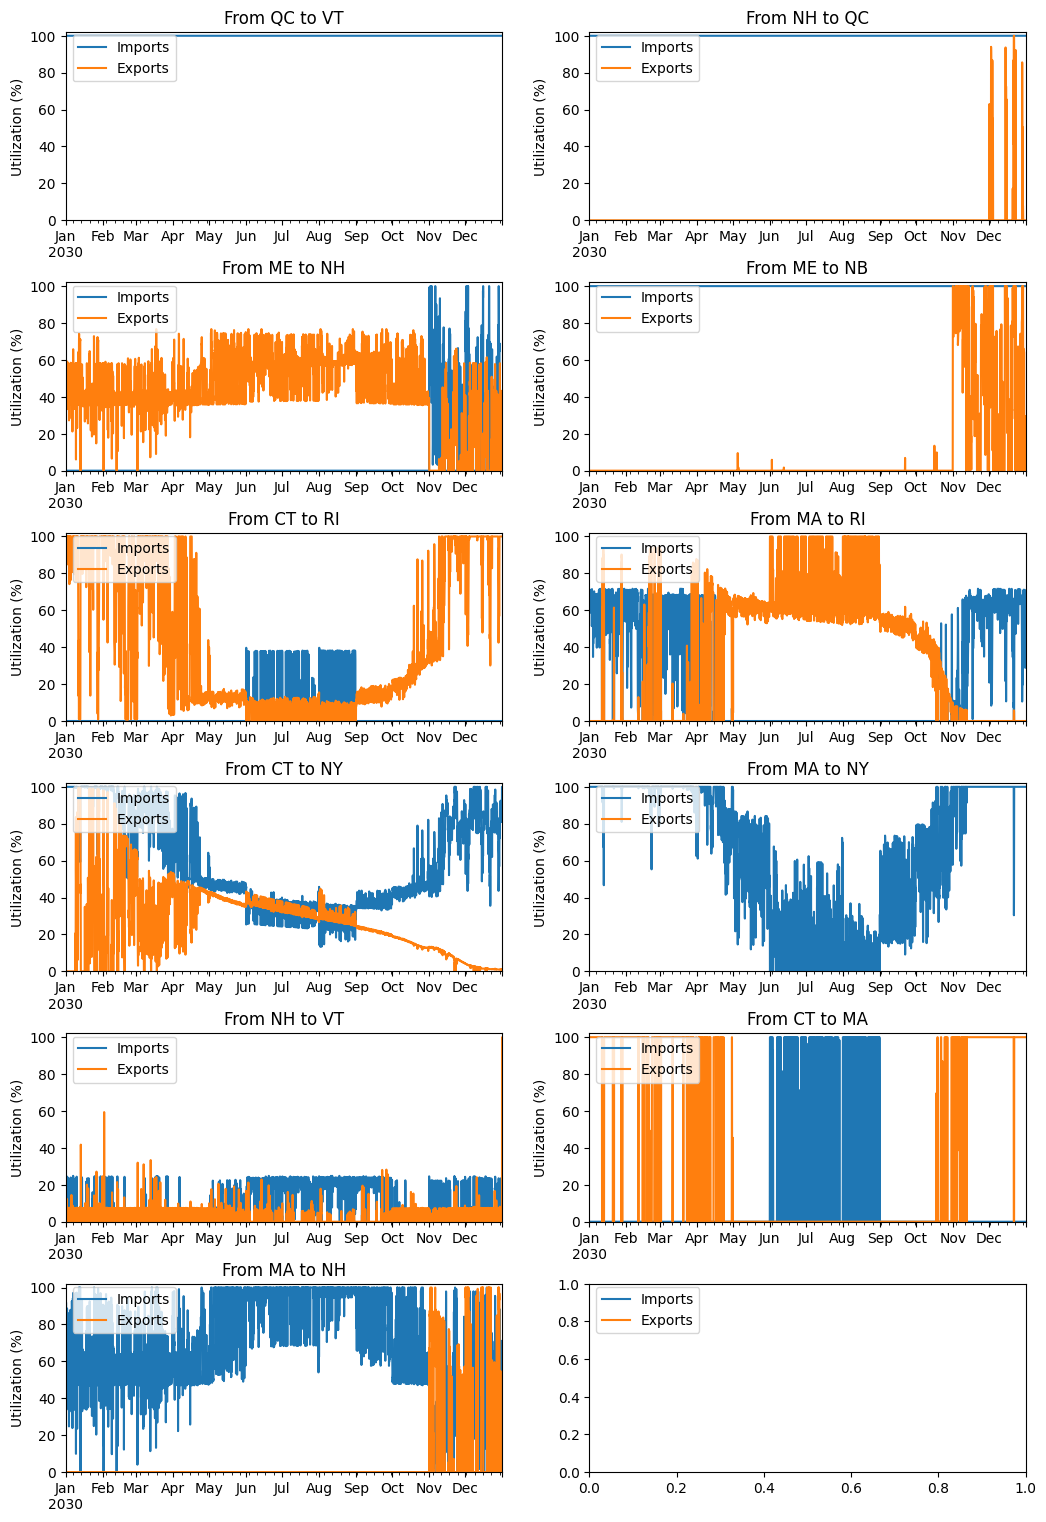

In [11]:
scenario = "hgas"
NETWORK = Path("..", "data", REGION, "raw", scenario, "networks", f"elec_s{SIMPL}_c{CLUSTERS}m_ec_lv1.0_1h-TCT_E-G.nc")
n = pypsa.Network(NETWORK)
fig, _ = plot_utilization(n)
save_f = Path(FIGURES, f"{scenario}.png")
save_f.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(save_f, dpi=300, bbox_inches="tight")